# Prueba de los diferentes modelos

## Instalación

In [1]:
#%pip install matplotlib
#%pip install numpy
#%pip install pandas
#%pip install pykan
#%pip install scipy
#%pip install scikit-learn
#%pip install seaborn
#%pip install tabpfn
#%pip install tensorflow
#%pip install tensorflow-probability
#%pip install tf-keras
#%pip install torch

## Cargar paquetes

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns
import tensorflow as tf
import tensorflow_probability as tfp
import tf_keras
import torch

from kan import KAN
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tabpfn import TabPFNRegressor

In [3]:
os.environ["HF_TOKEN"] = "HF_TOKEN_REMOVED"
seed = 42


## Métricas para evaluación

### **$R^2$ (Coeficiente de Determinación):**

- **Indica:** ¿Qué porcentaje del comportamiento físico ha entendido el modelo?

- Es la mejor forma de comparar modelos entre sí.
  - Un $R^2 = 1.0$ es perfecto.
  - Si da $0.85$, significa que el modelo explica el 85% de la variabilidad de la rugosidad, y el 15% restante es ruido o factores desconocidos.


### **MSE (Mean Squared Error):**

- **Indica:** ¿Qué tan graves son mis peores errores?

- Al elevar el error al cuadrado ($error^2$), castiga muchísimo los fallos grandes. Si la máquina falla por 10 micras, el MSE lo cuenta como 100 de penalización. Es la métrica favorita de las matemáticas para entrenar (optimizar) la red.


### **RMSE (Root Mean Squared Error):**

- **Indica:** En promedio, ¿por cuántas micras se está equivocando? (Dando más peso a los errores grandes).

- Tiene las mismas unidades que los datos ($\mu m$). Si el RMSE es $5.0$, se puede decir que "el modelo tiene una precisión de $\pm 5$ micras". Es mucho más intuitivo que el MSE.

### **MAE (Mean Absolute Error):**

- **Indica:** ¿Cuál es el error promedio real, sin exagerar los fallos puntuales?

- Es más justa y robusta. Si se tiene un solo dato de medición muy malo (un *outlier*), el RMSE se disparará, pero el MAE se mantendrá estable. Dice el error que se puede esperar en un día normal.

In [4]:
def evaluar_modelo(nombre_modelo, y_real, y_predicho):
    # Asegurar que tengan la misma forma (n_muestras, 1)
    y_real = y_real.reshape(-1, 1)
    y_predicho = y_predicho.reshape(-1, 1)
    
    # Calcular métricas
    r2 = r2_score(y_real, y_predicho)
    mse = mean_squared_error(y_real, y_predicho)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_real, y_predicho)
    
    print(f"--- Rendimiento: {nombre_modelo} ---")
    print(f"R² (Calidad de ajuste): {r2:.4f}  (Ideal: 1.0)")
    print(f"RMSE (Error típico):    {rmse:.4f} µm")
    print(f"MAE (Error absoluto):   {mae:.4f} µm")
    print(f"MSE:                    {mse:.4f}")
    print("-" * 30)
    
    return r2, rmse

## Preparación de Datos

In [5]:
# 1. CARGAR
df = pd.read_csv('../../data/ann_and_pso_data.csv')
df.head()

,Experiment no.,Nozzle temperature (C°),Layer height (μm),Print speed (mm/s),Nozzle diameter (mm),Infill density (%),Test1: surface roughness (µm),Test2: surface roughness (µm),Standard deviation
0,1,210,200,30,0.3,30,42.7,43.1,0.28
1,2,190,150,75,0.4,20,26.2,26.4,0.14
2,3,190,200,30,0.5,10,54.0,54.2,0.14
3,4,200,200,75,0.4,20,30.5,30.5,0.00
4,5,190,100,120,0.5,10,25.0,25.2,0.14


In [6]:
# Definir columnas
feature_cols = ['Nozzle temperature (C°)', 'Layer height (μm)', 'Print speed (mm/s)', 'Nozzle diameter (mm)', 'Infill density (%)']
target1_col = 'Test1: surface roughness (µm)'
target2_col = 'Test2: surface roughness (µm)'

X_raw = df[feature_cols].values
y1_raw = df[[target1_col]].values
y2_raw = df[[target2_col]].values

In [7]:
# 2. DIVIDIR POR EXPERIMENTO (Para evitar Data Leakage)
indices = np.arange(len(df))
# 80% Train, 20% Test (ajusta según necesites, el paper original usaba 70/15/15)
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)

In [8]:
# 3. FUNCIÓN DE APILADO (STACKING)
def stack_data(indices, X_full, y1_full, y2_full):
    # Seleccionar datos del subconjunto
    X_subset = X_full[indices]
    y1_subset = y1_full[indices]
    y2_subset = y2_full[indices]
    
    # Apilar: X sobre X, y1 sobre y2
    X_stacked = np.vstack([X_subset, X_subset])
    y_stacked = np.vstack([y1_subset, y2_subset])
    return X_stacked, y_stacked

X_train_stacked, y_train_stacked = stack_data(train_idx, X_raw, y1_raw, y2_raw)
X_test_stacked, y_test_stacked = stack_data(test_idx, X_raw, y1_raw, y2_raw)

In [9]:
# 4. ESCALAR (MinMax)
# Ajustamos el escalador SOLO con Train para simular un escenario real
scaler_X = MinMaxScaler().fit(X_train_stacked)
scaler_y = MinMaxScaler().fit(y_train_stacked)

X_train = scaler_X.transform(X_train_stacked)
y_train = scaler_y.transform(y_train_stacked)
X_test = scaler_X.transform(X_test_stacked)
y_test = scaler_y.transform(y_test_stacked)

print(f"Datos de Entrenamiento: {X_train.shape} muestras (Doble de experimentos)")

Datos de Entrenamiento: (68, 5) muestras (Doble de experimentos)


## Análisis de Componentes Principales (PCA) - Para entender la geometría de los datos

In [10]:
# Estandarizar (Crucial para PCA)
x_std = StandardScaler().fit_transform(X_raw)

In [11]:
# PCA de 2 Componentes
pca = PCA(n_components=2)
principalComponents = pca.fit_transform(x_std)
pca_df = pd.DataFrame(data=principalComponents, columns=['PC1', 'PC2'])

# Añadir datos para el gráfico
pca_df['Roughness'] = (df['Test1: surface roughness (µm)'] + df['Test2: surface roughness (µm)']) / 2

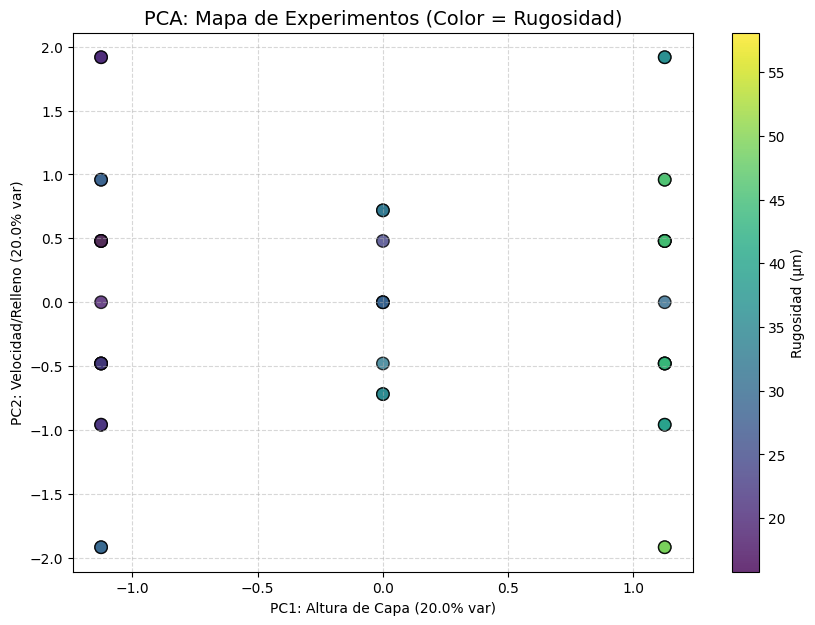

                         PC1       PC2
Nozzle temperature (C°)  0.0 -0.000000
Layer height (μm)        1.0 -0.000000
Print speed (mm/s)       0.0  0.639602
Nozzle diameter (mm)    -0.0 -0.426401
Infill density (%)      -0.0 -0.639602


In [12]:
# Graficar
plt.figure(figsize=(10, 7))
sc = plt.scatter(pca_df['PC1'], pca_df['PC2'], c=pca_df['Roughness'], 
                 cmap='viridis', s=80, edgecolors='k', alpha=0.8)

plt.title('PCA: Mapa de Experimentos (Color = Rugosidad)', fontsize=14)
plt.xlabel(f'PC1: Altura de Capa ({pca.explained_variance_ratio_[0]:.1%} var)')
plt.ylabel(f'PC2: Velocidad/Relleno ({pca.explained_variance_ratio_[1]:.1%} var)')
plt.colorbar(sc, label='Rugosidad (µm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# Ver qué variable pesa más en cada componente
print(pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_cols))

1. **El que predomina es la Altura de Capa (PC1)**

- El Componente Principal 1 (Eje X). La matriz de cargas indica que este eje es casi 100% Layer height.
- ay un gradiente claro de izquierda a derecha.
  - **Izquierda (Morado/Azul):** Rugosidad baja (~20 µm).
  - **Derecha (Amarillo/Verde):** Rugosidad alta (~50 µm).
- La altura de capa es, por lejos, el factor más determinante. A mayor altura de capa, mayor rugosidad. Esto confirma el fenómeno físico del "efecto escalera" en impresión 3D.

2. **La complejidad está en el Eje Y (PC2)**

- El Componente Principal 2 (Eje Y) es una mezcla de Speed (Velocidad), Infill (Relleno) y Diameter (Boquilla).
- Aquí los colores están más mezclados. No hay una separación tan nítida de arriba a abajo como la hay de izquierda a derecha.
- Esto sugiere que la velocidad y el relleno afectan la rugosidad de manera menos lineal o más interactiva. Es aquí los modelos BNN, KAN, TabPFN van a intentar entender mejor esta "mezcla" del Eje Y.

| Modelo | Pronóstico basado en el PCA |
|--------|-----------------------------|
|  KAN   | Tiene ventaja. KAN es excelente encontrando funciones matemáticas puras. La relación con la Altura de Capa parece muy fuerte y suave, algo que KAN modelará con un spline casi perfecto. |
| TabPFN | Debería ser muy robusto. Al tener variables independientes (baja covarianza), TabPFN puede explotar su arquitectura de Transformer para atender a cada columna por separado sin confundirse. |
|  BNN   | Podría sufrir un poco más si hay mucho "ruido" en la zona central del gráfico, pero su ventaja será decirte: "Aquí en el medio no estoy seguro". |


## Random Forest

El método estándar en Random Forest se llama "Disminución Media de la Impureza" (MDI).

El modelo es un árbol de decisiones que hace preguntas para separar tus datos.

1. **El objetivo:** Reducir la varianza (el error) en la predicción de la rugosidad.

2. **La pregunta:** El árbol prueba todas las variables. Por ejemplo:

  - ¿Si divido los datos por Temperatura > 200°C? (El error baja un poquito).

  - ¿Si divido los datos por Altura de Capa > 0.15mm? (El error baja muchísimo).

3. **El puntaje:** Como dividir por "Altura de Capa" redujo más el error, esa variable gana más puntos.

4. **El promedio:** Como un Random Forest tiene (por ejemplo) 100 árboles, se promedia el puntaje de cada variable en todos los árboles.

In [13]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=seed)
rf.fit(X_train, y_train)

C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\sklearn\base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [14]:
importancia = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia': rf.feature_importances_
}).sort_values('Importancia', ascending=False)

importancia.head()

,Variable,Importancia
1,Layer height (μm),0.496344
3,Nozzle diameter (mm),0.223473
2,Print speed (mm/s),0.123403
4,Infill density (%),0.093874
0,Nozzle temperature (C°),0.062906


C:\Users\Erick\AppData\Local\Temp\ipykernel_37972\1545515646.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')


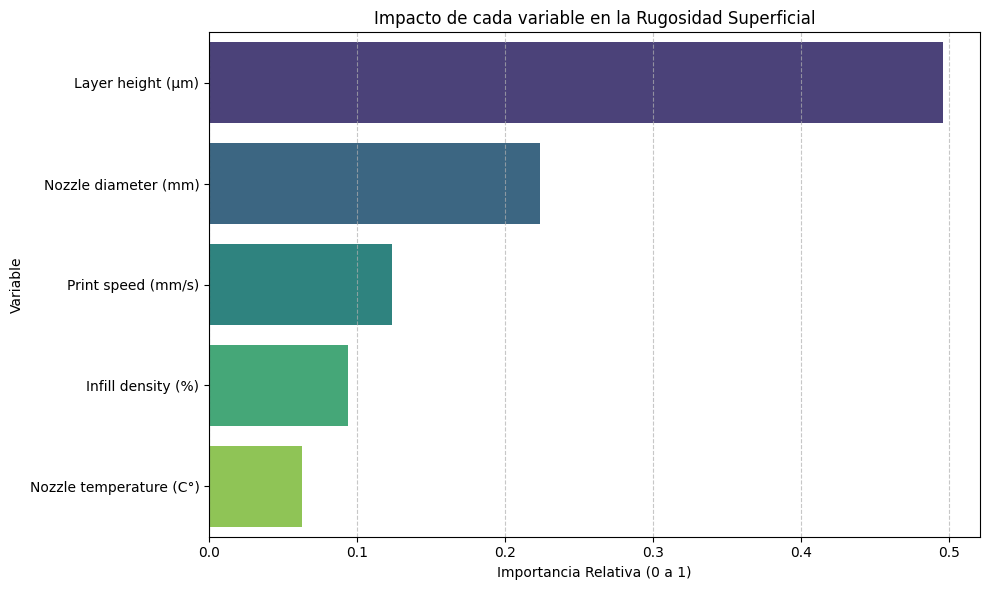

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=importancia, palette='viridis')
plt.title('Impacto de cada variable en la Rugosidad Superficial')
plt.xlabel('Importancia Relativa (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Modelo 1: Bayesian Neural Network (BNN)

In [16]:
tfd = tfp.distributions
tfpl = tfp.layers

In [17]:
# --- ARQUITECTURA BNN ---
# El término de divergencia KL regula la incertidumbre
kl_divergence_function = (lambda q, p, _: tfp.distributions.kl_divergence(q, p) / 
                          (tf.cast(len(X_train), dtype=tf.float32) * 1.0))

model_bnn = tf_keras.Sequential([
    # Entrada: 5 características
    tf_keras.layers.Input(shape=(5,)),
    
    # Capas Ocultas Bayesianas (DenseFlipout)
    tfpl.DenseFlipout(8, activation='swish', kernel_divergence_fn=kl_divergence_function),

    # Salida Probabilística (Media y Desviación Estándar)
    tfpl.DenseFlipout(2, kernel_divergence_fn=kl_divergence_function),
    tfpl.DistributionLambda(lambda t: tfd.Normal(
        loc=t[..., :1], 
        scale=1e-3 + tf.math.softplus(0.01 * t[..., 1:])
    ))
])

C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tensorflow_probability\python\layers\util.py:99: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  loc = add_variable_fn(
C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tensorflow_probability\python\layers\util.py:109: UserWarning: `layer.add_variable` is deprecated and will be removed in a future version. Please use the `layer.add_weight()` method instead.
  untransformed_scale = add_variable_fn(
C:\Users\Erick\AppData\Roaming\Python\Python312\site-packages\tf_keras\src\initializers\initializers.py:121: UserWarning: The initializer RandomNormal is unseeded and being called multiple times, which will return identical values each time (even if the initializer is unseeded). Please update your code to provide a seed to the initializer, or avoid using the same initializer instance more than once.
  warnings.warn(


In [18]:
# Compilar
optimizer = tf_keras.optimizers.Adam(learning_rate=0.005)
model_bnn.compile(optimizer=optimizer, loss=lambda y, model: -model.log_prob(y))

In [19]:
# Entrenar
early_stop = tf_keras.callbacks.EarlyStopping(monitor='val_loss', patience=200)

history = model_bnn.fit(
    X_train, y_train, 
    epochs=5000,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/5000

3/3 [==============================] - 1s 126ms/step - loss: 2.9514 - val_loss: 2.9108
Epoch 2/5000
3/3 [==============================] - 0s 16ms/step - loss: 2.9045 - val_loss: 2.8631
Epoch 3/5000
3/3 [==============================] - 0s 17ms/step - loss: 2.8565 - val_loss: 2.8198
Epoch 4/5000
3/3 [==============================] - 0s 18ms/step - loss: 2.8125 - val_loss: 2.7713
Epoch 5/5000
3/3 [==============================] - 0s 16ms/step - loss: 2.7619 - val_loss: 2.7375
Epoch 6/5000
3/3 [==============================] - 0s 17ms/step - loss: 2.7269 - val_loss: 2.6979
Epoch 7/5000
3/3 [==============================] - 0s 14ms/step - loss: 2.6879 - val_loss: 2.6625
Epoch 8/5000
3/3 [==============================] - 0s 18ms/step - loss: 2.6599 - val_loss: 2.6489
Epoch 9/5000
3/3 [==============================] - 0s 17ms/step - loss: 2.6373 - val_loss: 2.6261
Epoch 10/5000
3/3 [==============================] - 0s 15ms/step - loss: 2.6218 - val_loss: 2.6098
Epoch 1

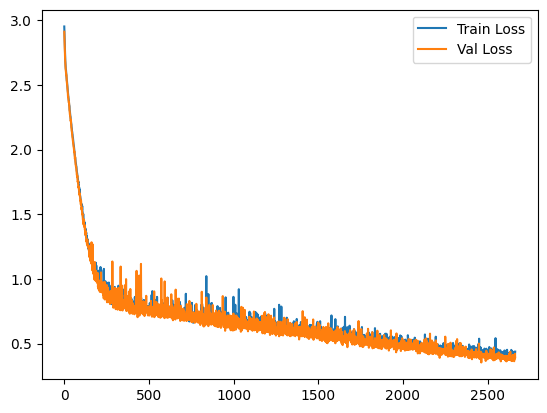

In [20]:
# Visualizar Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.show()

## Modelo 2: Kolmogorov-Arnold Network (KAN)

In [21]:
# Convertir datos a tensores de PyTorch
dataset = {
    'train_input': torch.from_numpy(X_train).float(),
    'train_label': torch.from_numpy(y_train).float(),
    'test_input': torch.from_numpy(X_test).float(),
    'test_label': torch.from_numpy(y_test).float()
}

In [22]:
# --- ARQUITECTURA KAN ---
# width=[5, 5, 1]: 
#   5 entradas (tus variables)
#   5 neuronas en capa oculta (puedes aumentar esto si falta precisión)
#   1 salida (rugosidad)
model_kan = KAN(width=[5, 5, 1], grid=5, k=3, seed=seed)

checkpoint directory created: ./model
saving model version 0.0


In [23]:
# Entrenar
# 'opt="LBFGS"' suele ser mejor para KANs en problemas de regresión física suave
results = model_kan.fit(dataset, opt="LBFGS", steps=50, lamb=0.01)

| train_loss: 9.42e-02 | test_loss: 3.19e-02 | reg: 3.54e+00 | : 100%|█| 50/50 [00:05<00:00,  8.37it

saving model version 0.1


KAN Entrenada.


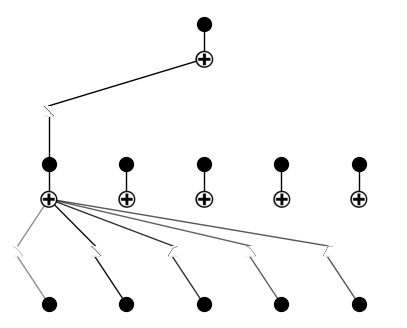

In [24]:
# Visualizar la estructura aprendida
model_kan.plot()
print("KAN Entrenada.")

## Modelo 3: Tabular Prior-Data Fitted Network (TabPFN)

TabPFN v2.5 es un modelo protegido ("Gated") en Hugging Face. Esto significa que no se puede descargar automáticamente sin antes aceptar su licencia de uso (que es gratuita para investigación/uso no comercial).

Se tiene que autorizarte una única vez siguiendo estos pasos:

1. Aceptar la licencia en Hugging Face.
  1. Ir a la [página oficial del modelo](https://huggingface.co/Prior-Labs/tabpfn_2_5).
  2. Iniciar sesión (o crear una cuenta).
  3. Presionar el botón o formulario para aceptar las condiciones de uso.
  4. Hacer clic en "Agree" o "Access repository".
2. Obtener tu Token de Acceso:
    1. Ir a [Configuración de Tokens](https://huggingface.co/settings/tokens).
    2. Crear un nuevo token (selecciona el tipo "Read").
    3. Copiarlo (empieza por hf_...).
3. Añadir el token al código.

In [25]:
# --- ARQUITECTURA TABPFN ---
regressor = TabPFNRegressor(device='cpu', n_estimators=8)

In [26]:
print("Entrenando TabPFN...")
# .fit() carga los datos de contexto (no hay back-propagation tradicional)
regressor.fit(X_train, y_train.ravel())

Entrenando TabPFN...


,n_estimators,8
,categorical_features_indices,None
,softmax_temperature,0.9
,average_before_softmax,False
,model_path,'auto'
,device,'cpu'
,ignore_pretraining_limits,False
,inference_precision,'auto'
,fit_mode,'fit_preprocessors'
,memory_saving_mode,'auto'
,random_state,0


## Evaluar modelos

In [27]:
# BNN
# Inferencia estocástica (Monte Carlo)
num_runs = 100
preds_escaladas = [model_bnn(X_test).mean().numpy() for _ in range(num_runs)]
y_pred_mean_scaled = np.array(preds_escaladas).mean(axis=0)

# Des-escalar para tener micras reales
y_test_real = scaler_y.inverse_transform(y_test)
y_pred_bnn_real = scaler_y.inverse_transform(y_pred_mean_scaled)

# Evaluar
evaluar_modelo("BNN (Bayesiana)", y_test_real, y_pred_bnn_real)


--- Rendimiento: BNN (Bayesiana) ---
R² (Calidad de ajuste): -0.0064  (Ideal: 1.0)
RMSE (Error típico):    10.2293 µm
MAE (Error absoluto):   8.6673 µm
MSE:                    104.6389
------------------------------


(-0.006377836746106924, np.float64(10.229317824900612))

In [28]:
# TabPFN
# Predecir
y_pred_tab_scaled = regressor.predict(X_test)

# Des-escalar
# TabPFN a veces devuelve arreglos de forma (N,), necesitamos (N,1)
y_pred_tab_real = scaler_y.inverse_transform(y_pred_tab_scaled.reshape(-1, 1))

# Evaluar
evaluar_modelo("TabPFN", y_test_real, y_pred_tab_real)

--- Rendimiento: TabPFN ---
R² (Calidad de ajuste): 0.9639  (Ideal: 1.0)
RMSE (Error típico):    1.9362 µm
MAE (Error absoluto):   1.4866 µm
MSE:                    3.7489
------------------------------


(0.9639449435772709, np.float64(1.9361956059817984))

In [29]:
# Predecir (usando el tensor de test que creamos antes)
# dataset['test_input'] ya es un tensor
pred_tensor = model_kan(dataset['test_input'])

# Convertir a Numpy y Des-escalar
y_pred_kan_scaled = pred_tensor.detach().numpy()
y_pred_kan_real = scaler_y.inverse_transform(y_pred_kan_scaled)

# Evaluar
# Nota: y_test_real es el mismo para todos, no hace falta recalcularlo
evaluar_modelo("KAN", y_test_real, y_pred_kan_real)

--- Rendimiento: KAN ---
R² (Calidad de ajuste): 0.9836  (Ideal: 1.0)
RMSE (Error típico):    1.3068 µm
MAE (Error absoluto):   0.9979 µm
MSE:                    1.7076
------------------------------


(0.983576762692631, np.float64(1.3067590742653157))

## Resumen visual (comparación de los modelos)

In [30]:
# 1. LISTAS DE DATOS
# Asegúrate de que estas variables tengan tus datos reales des-escalados
modelos = ['BNN', 'KAN', 'TabPFN']
predicciones = [y_pred_bnn_real, y_pred_kan_real, y_pred_tab_real]
colores = ['#4c72b0', '#55a868', '#c44e52'] # Azul, Verde, Rojo (paleta seaborn)

In [31]:
# 2. CALCULAR MÉTRICAS AUTOMÁTICAMENTE
r2_vals = []
rmse_vals = []
mae_vals = []
mse_vals = []

for pred in predicciones:
    # Aplanar arrays por seguridad (convertir matrices n x 1 a vectores n)
    pred_flat = pred.ravel()
    y_real_flat = y_test_real.ravel()
    
    # Calcular
    r2_vals.append(r2_score(y_real_flat, pred_flat))
    mse = mean_squared_error(y_real_flat, pred_flat)
    mse_vals.append(mse)
    rmse_vals.append(np.sqrt(mse))
    mae_vals.append(mean_absolute_error(y_real_flat, pred_flat))

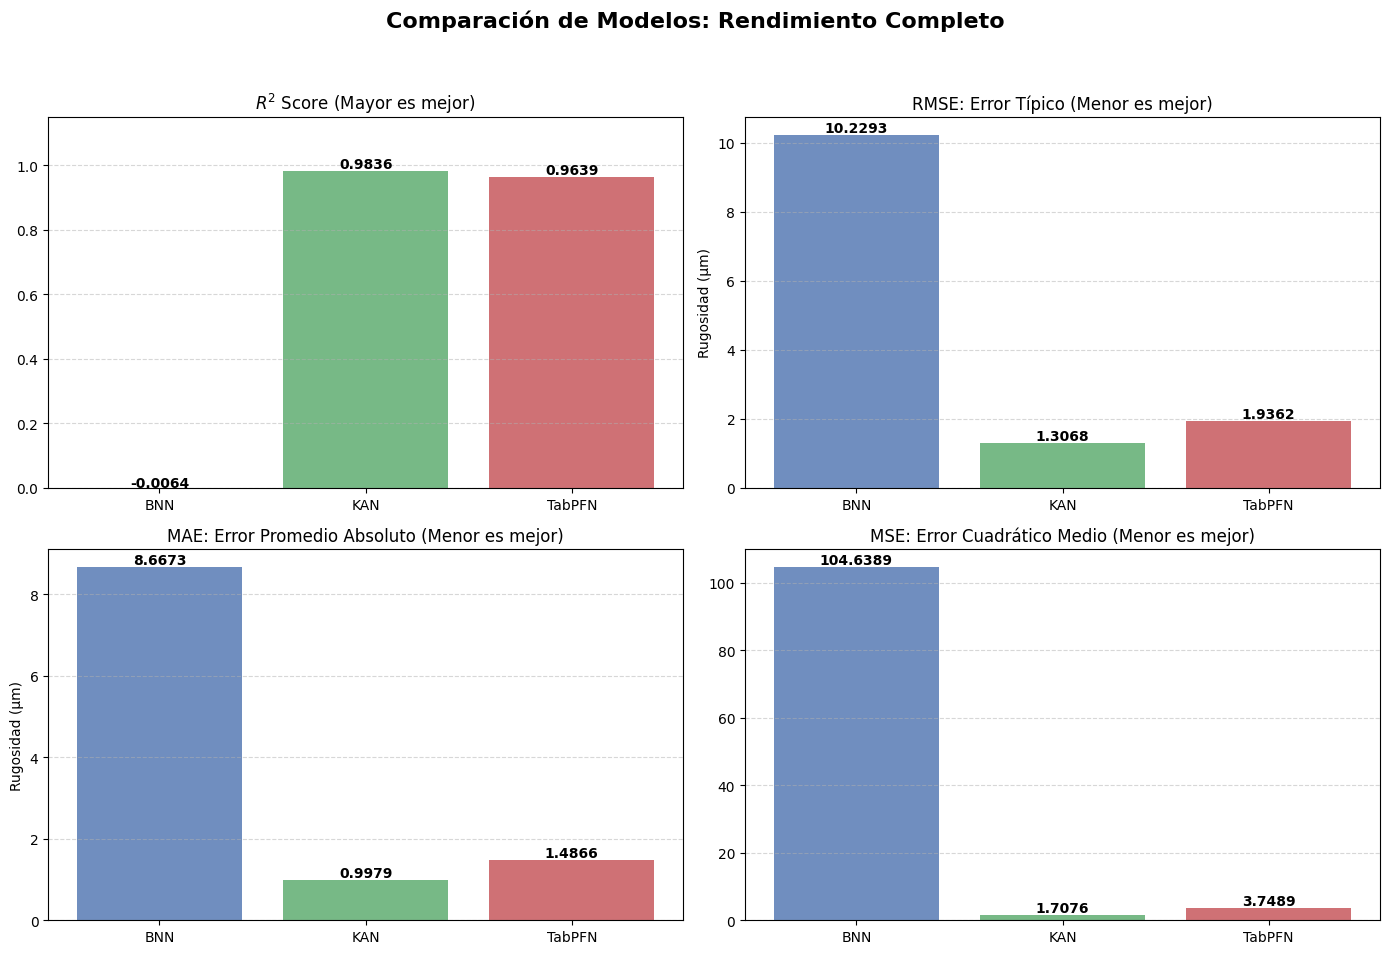

In [32]:
# 3. CREAR EL GRÁFICO (Panel 2x2)
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Comparación de Modelos: Rendimiento Completo', fontsize=16, fontweight='bold')

# Función auxiliar para poner el valor numérico encima de cada barra
def add_labels(ax, values, is_r2=False):
    for i, v in enumerate(values):
        # Si es R2 y es muy alto, ajustamos el límite para que quepa
        if is_r2 and v > 0.95: 
            ax.set_ylim(0, 1.15)
        
        ax.text(i, v, f"{v:.4f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

# --- Gráfico A: R2 (Calidad de Ajuste) ---
axs[0, 0].bar(modelos, r2_vals, color=colores, alpha=0.8)
axs[0, 0].set_title('$R^2$ Score (Mayor es mejor)', fontsize=12)
axs[0, 0].set_ylim(0, 1.1) # R2 siempre es máximo 1
axs[0, 0].grid(axis='y', linestyle='--', alpha=0.5)
add_labels(axs[0, 0], r2_vals, is_r2=True)

# --- Gráfico B: RMSE (Error Típico en Micras) ---
axs[0, 1].bar(modelos, rmse_vals, color=colores, alpha=0.8)
axs[0, 1].set_title('RMSE: Error Típico (Menor es mejor)', fontsize=12)
axs[0, 1].set_ylabel('Rugosidad (µm)')
axs[0, 1].grid(axis='y', linestyle='--', alpha=0.5)
add_labels(axs[0, 1], rmse_vals)

# --- Gráfico C: MAE (Error Absoluto) ---
axs[1, 0].bar(modelos, mae_vals, color=colores, alpha=0.8)
axs[1, 0].set_title('MAE: Error Promedio Absoluto (Menor es mejor)', fontsize=12)
axs[1, 0].set_ylabel('Rugosidad (µm)')
axs[1, 0].grid(axis='y', linestyle='--', alpha=0.5)
add_labels(axs[1, 0], mae_vals)

# --- Gráfico D: MSE (Castigo a errores grandes) ---
axs[1, 1].bar(modelos, mse_vals, color=colores, alpha=0.8)
axs[1, 1].set_title('MSE: Error Cuadrático Medio (Menor es mejor)', fontsize=12)
axs[1, 1].grid(axis='y', linestyle='--', alpha=0.5)
add_labels(axs[1, 1], mse_vals)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## **Tabla comparativa 8**

In [33]:
# 1. DATOS DE VALIDACIÓN (Tabla 8 del Paper)
# Columnas 0-4: Entradas (X)
# Columna 5: Resultado reportado en el paper (Target)
data_table_8 = np.array([
    [200.494, 100.0,  91.086, 0.3, 24.599, 12.382],
    [190.000, 100.0,  99.562, 0.3, 24.146, 10.874],
    [190.000, 100.0,  96.992, 0.3, 30.000, 12.022],
    [190.000, 100.0,  99.045, 0.3, 24.277, 10.872],
    [201.484, 100.0,  90.305, 0.3, 24.516, 12.389],
    [190.000, 100.0, 102.000, 0.3, 23.966, 10.953],
    [190.000, 100.0,  98.918, 0.3, 24.306, 10.873],
    [190.000, 100.0,  99.084, 0.3, 24.367, 10.871],
    [190.000, 100.0,  98.942, 0.3, 24.436, 10.872],
    [190.000, 100.0,  94.636, 0.3, 25.178, 11.082]
])

# Separar X (entradas)
X_validation = data_table_8[:, 0:5]

# ESCALAR ENTRADAS
# Nota: Usamos el mismo scaler_X entrenado previamente
X_val_scaled = scaler_X.transform(X_validation)

In [34]:
# ---------------------------------------------------------
# 2. GENERAR PREDICCIONES CON CADA MODELO
# ---------------------------------------------------------

# A) BNN (Bayesian Neural Network) - Requiere Muestreo Monte Carlo
preds_bnn_runs = [model_bnn(X_val_scaled).mean().numpy() for _ in range(num_runs)]
pred_bnn_scaled = np.array(preds_bnn_runs).mean(axis=0)
pred_bnn_real = scaler_y.inverse_transform(pred_bnn_scaled).flatten()

# B) KAN (Kolmogorov-Arnold Network) - Requiere Tensores PyTorch
tensor_val = torch.from_numpy(X_val_scaled).float()
pred_kan_scaled = model_kan(tensor_val).detach().numpy()
pred_kan_real = scaler_y.inverse_transform(pred_kan_scaled).flatten()

# C) TabPFN (Transformer) - Predicción Directa
pred_tab_scaled = regressor.predict(X_val_scaled)
# Asegurar forma (N, 1) para des-escalar
pred_tab_real = scaler_y.inverse_transform(pred_tab_scaled.reshape(-1, 1)).flatten()

In [35]:
# ---------------------------------------------------------
# 3. CONSTRUIR TABLA COMPARATIVA
# ---------------------------------------------------------
columns = [
    "Nozzle Temp (°C)", 
    "Layer Height (µm)", 
    "Speed (mm/s)", 
    "Diameter (mm)", 
    "Infill (%)",
    "Paper Value (µm)" # Valor objetivo del paper
]

# Crear DataFrame base con datos originales
df_results = pd.DataFrame(data_table_8, columns=columns)

# Agregar las predicciones de nuestros modelos
df_results["BNN Pred (µm)"] = pred_bnn_real
df_results["KAN Pred (µm)"] = pred_kan_real
df_results["TabPFN Pred (µm)"] = pred_tab_real

# Calcular error promedio respecto al valor del paper para cada fila
df_results["BNN Error (%)"] = abs(df_results["Paper Value (µm)"] - df_results["BNN Pred (µm)"]) / df_results["Paper Value (µm)"] * 100
df_results["KAN Error (%)"] = abs(df_results["Paper Value (µm)"] - df_results["KAN Pred (µm)"]) / df_results["Paper Value (µm)"] * 100
df_results["TabPFN Error (%)"] = abs(df_results["Paper Value (µm)"] - df_results["TabPFN Pred (µm)"]) / df_results["Paper Value (µm)"] * 100

In [36]:
# ---------------------------------------------------------
# 4. AGREGAR FILA DE PROMEDIOS
# ---------------------------------------------------------
avg_row = df_results.mean()
df_avg = pd.DataFrame(avg_row).T
df_avg.index = ["Average"]

# Concatenar
df_final = pd.concat([df_results, df_avg])

# Formato visual
pd.set_option('display.precision', 3)
display(df_final)

,Nozzle Temp (°C),Layer Height (µm),Speed (mm/s),Diameter (mm),Infill (%),Paper Value (µm),BNN Pred (µm),KAN Pred (µm),TabPFN Pred (µm),BNN Error (%),KAN Error (%),TabPFN Error (%)
0,200.494,100.0,91.086,0.3,24.599,12.382,33.547,18.043,16.420,170.931,45.723,32.614
1,190.000,100.0,99.562,0.3,24.146,10.874,33.515,17.174,15.459,208.215,57.932,42.164
2,190.000,100.0,96.992,0.3,30.000,12.022,34.094,17.260,15.169,183.595,43.572,26.180
3,190.000,100.0,99.045,0.3,24.277,10.872,33.562,17.178,15.475,208.704,58.004,42.340
4,201.484,100.0,90.305,0.3,24.516,12.389,33.769,18.164,16.491,172.573,46.613,33.107
5,190.000,100.0,102.000,0.3,23.966,10.953,33.583,17.149,15.497,206.610,56.565,41.490
6,190.000,100.0,98.918,0.3,24.306,10.873,33.628,17.179,15.437,209.283,58.001,41.974
7,190.000,100.0,99.084,0.3,24.367,10.871,33.572,17.177,15.444,208.822,58.005,42.069
8,190.000,100.0,98.942,0.3,24.436,10.872,33.637,17.178,15.449,209.392,58.000,42.094
9,190.000,100.0,94.636,0.3,25.178,11.082,33.659,17.233,15.435,203.723,55.505,39.282


## Figura 8: Regresiones

In [37]:
# Función auxiliar para des-escalar
def to_real(data_scaled):
    return scaler_y.inverse_transform(data_scaled.reshape(-1, 1)).flatten()

# Datos Reales (Ground Truth)
y_train_real = to_real(y_train)
y_test_real = to_real(y_test)
y_all_real = np.concatenate([y_train_real, y_test_real])

# --- PREDICCIONES BNN ---
# Promedio de 50 pasadas para suavizar
pred_train_bnn = np.array([model_bnn(X_train).mean().numpy() for _ in range(50)]).mean(axis=0)
pred_test_bnn = np.array([model_bnn(X_test).mean().numpy() for _ in range(50)]).mean(axis=0)
# Convertir a real
p_train_bnn_real = to_real(pred_train_bnn)
p_test_bnn_real = to_real(pred_test_bnn)
p_all_bnn_real = np.concatenate([p_train_bnn_real, p_test_bnn_real])

# --- PREDICCIONES KAN ---
# KAN requiere tensores
tensor_train = torch.from_numpy(X_train).float()
tensor_test = torch.from_numpy(X_test).float()
# Predecir y desconectar del grafo (detach)
pred_train_kan = model_kan(tensor_train).detach().numpy()
pred_test_kan = model_kan(tensor_test).detach().numpy()
# Convertir a real
p_train_kan_real = to_real(pred_train_kan)
p_test_kan_real = to_real(pred_test_kan)
p_all_kan_real = np.concatenate([p_train_kan_real, p_test_kan_real])

# --- PREDICCIONES TABPFN ---
pred_train_tab = regressor.predict(X_train)
pred_test_tab = regressor.predict(X_test)
# Convertir a real
p_train_tab_real = to_real(pred_train_tab)
p_test_tab_real = to_real(pred_test_tab)
p_all_tab_real = np.concatenate([p_train_tab_real, p_test_tab_real])

In [38]:
# --- 2. FUNCIÓN DE PLOTEO (Tu función modificada) ---
def plot_regression(ax, t, o, title, color):
    """
    t: Target (Valor Real)
    o: Output (Predicción)
    """
    slope, intercept, r_value, _, _ = stats.linregress(t, o)
    
    # Scatter de datos
    ax.scatter(t, o, facecolors='none', edgecolors=color, alpha=0.6, label='Data')
    
    # Línea de Ajuste (Regresión)
    # Creamos puntos para la línea basados en el rango de los datos
    line_x = np.linspace(t.min(), t.max(), 100)
    ax.plot(line_x, slope*line_x + intercept, 'k-', linewidth=1.5, label=f'Fit (R={r_value:.4f})')
    
    # Línea Ideal Y=T (45 grados)
    min_val = min(t.min(), o.min())
    max_val = max(t.max(), o.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', alpha=0.5, linewidth=1, label='Ideal Y=T')
    
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('Target (Real) [µm]', fontsize=9)
    ax.set_ylabel('Output (Pred) [µm]', fontsize=9)
    ax.legend(fontsize=8, loc='upper left')
    ax.grid(True, linestyle=':', alpha=0.6)

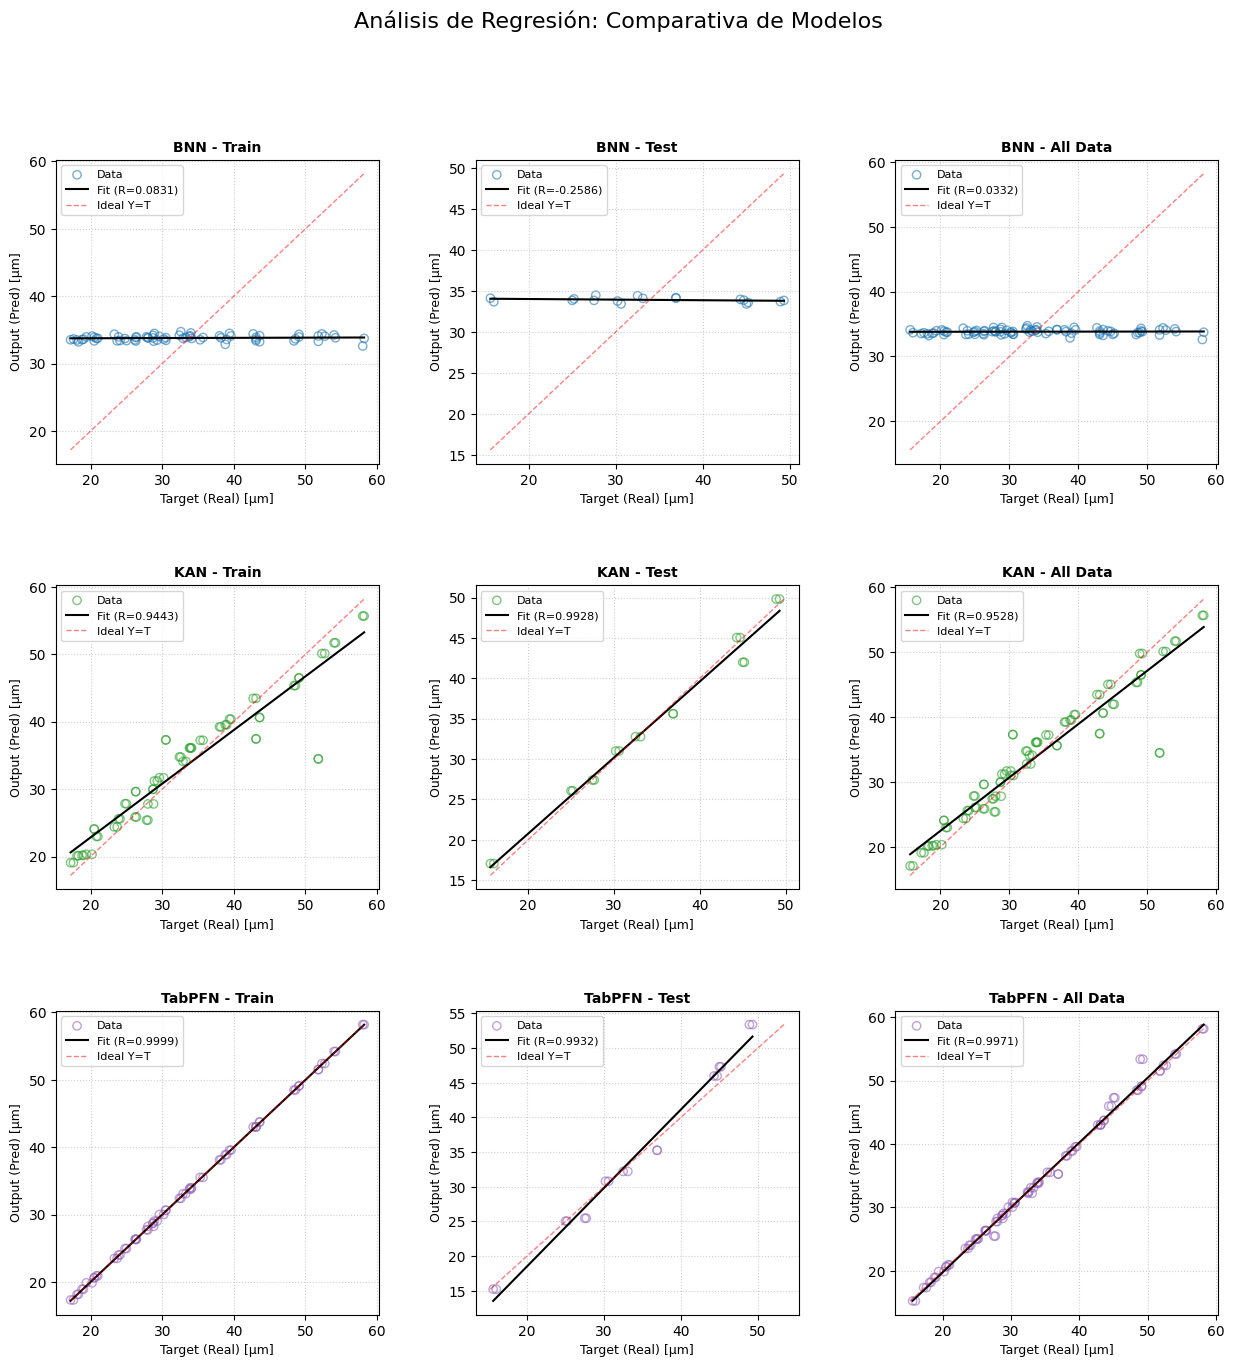

In [39]:
# --- 3. GENERAR LA FIGURA 3x3 ---
fig, axs = plt.subplots(3, 3, figsize=(15, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Definir filas y datos
filas = [
    ("BNN", '#1f77b4', p_train_bnn_real, p_test_bnn_real, p_all_bnn_real),   # Azul
    ("KAN", '#2ca02c', p_train_kan_real, p_test_kan_real, p_all_kan_real),   # Verde
    ("TabPFN", '#9467bd', p_train_tab_real, p_test_tab_real, p_all_tab_real) # Morado
]

for i, (model_name, color, p_train, p_test, p_all) in enumerate(filas):
    # Columna 1: Train
    plot_regression(axs[i, 0], y_train_real, p_train, f"{model_name} - Train", color)
    
    # Columna 2: Test
    plot_regression(axs[i, 1], y_test_real, p_test, f"{model_name} - Test", color)
    
    # Columna 3: All
    plot_regression(axs[i, 2], y_all_real, p_all, f"{model_name} - All Data", color)

fig.suptitle('Análisis de Regresión: Comparativa de Modelos', fontsize=16)
plt.show()

## Figura 9: $R^2$, MSE, RMSE y MAE

In [40]:
# --- DATOS (Asegúrate de tener tus variables reales cargadas) ---
# model_names = ["BNN", "KAN", "TabPFN"]
# predictions = [p_all_bnn_real, p_all_kan_real, p_all_tab_real]
# real_data = y_all_real

# Lista combinada para iterar
modelos_data = [
    ("BNN", p_all_bnn_real, 'magenta'),
    ("KAN", p_all_kan_real, 'green'),
    ("TabPFN", p_all_tab_real, 'purple')
]

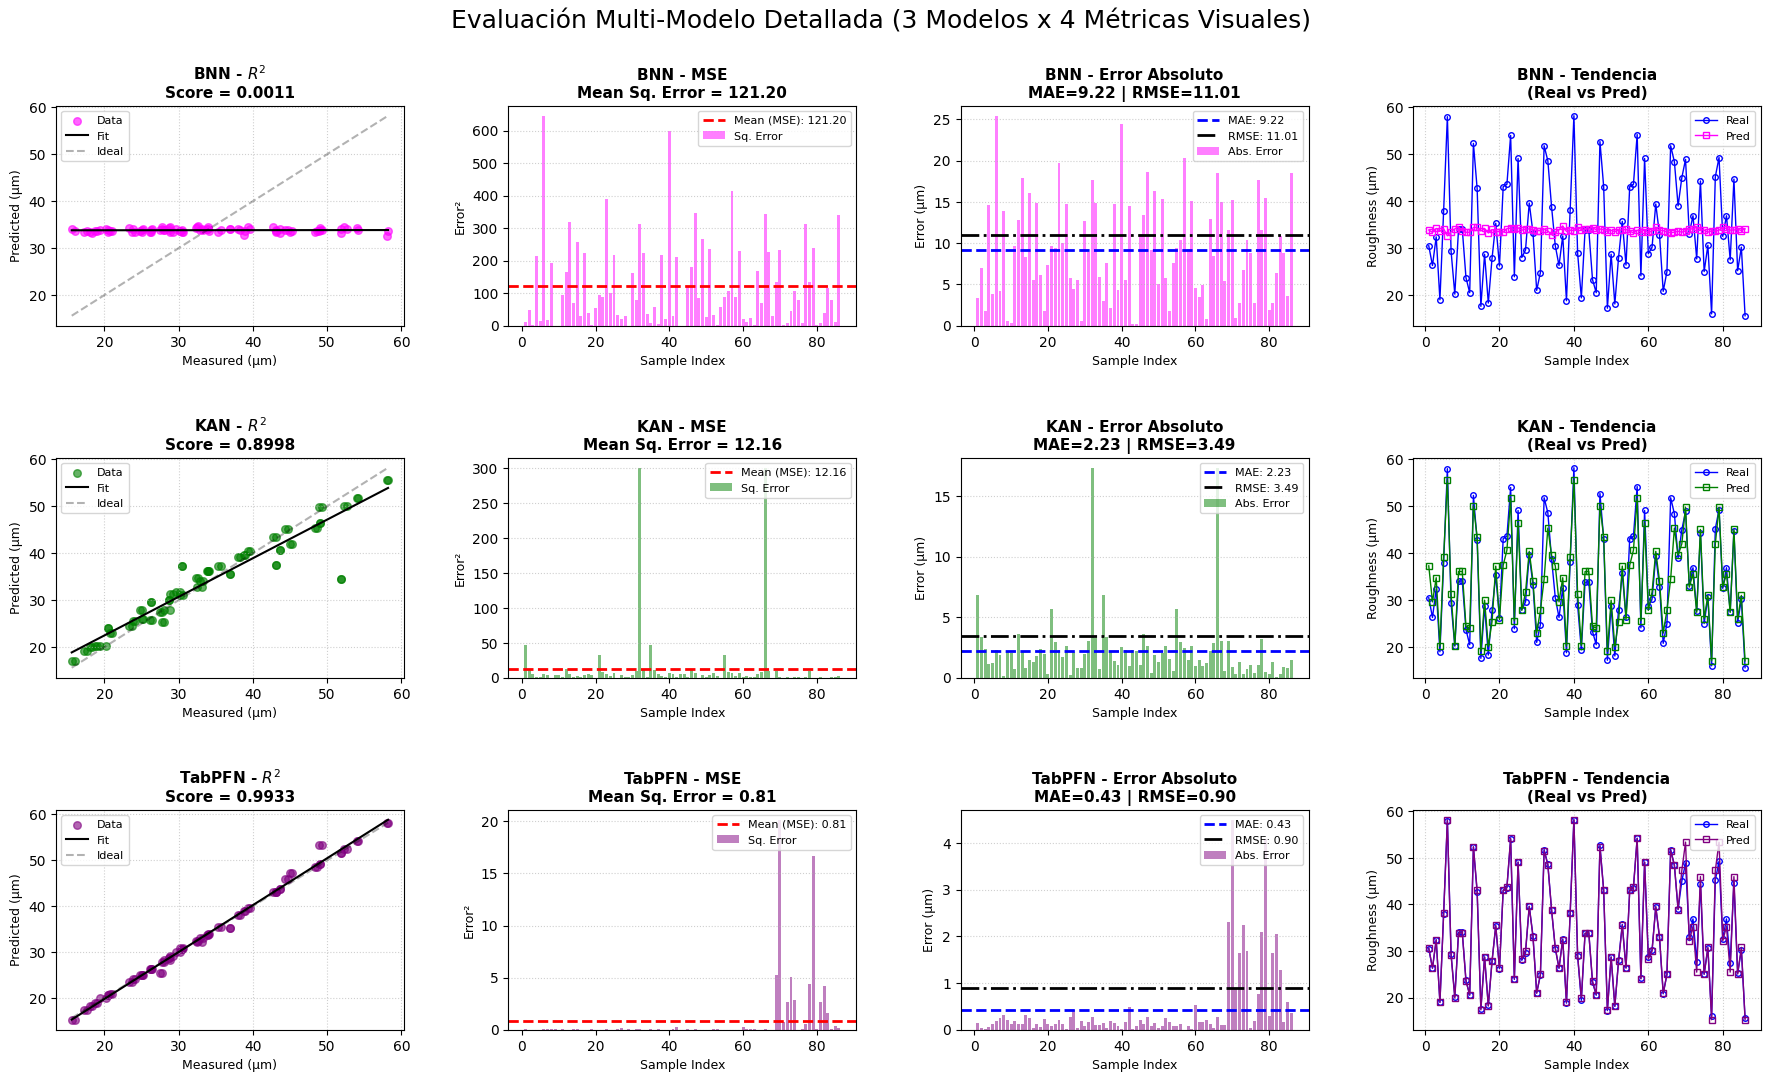

In [41]:
# --- CONFIGURACIÓN FIGURA 3x4 ---
fig, axs = plt.subplots(3, 4, figsize=(22, 12))
# Ajustes de espacio para que no se amontonen los títulos
plt.subplots_adjust(hspace=0.6, wspace=0.3)

indices = np.arange(1, len(y_all_real) + 1)

for i, (name, y_pred, color) in enumerate(modelos_data):
    # 1. Cálculos Matemáticos
    r2 = r2_score(y_all_real, y_pred)
    mse = mean_squared_error(y_all_real, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_all_real, y_pred)

    # Residuales para gráficos de barras
    residuals = y_all_real - y_pred
    squared_errors = residuals ** 2
    abs_errors = np.abs(residuals)

    # --- GRÁFICA 1: Scatter Plot (R2) ---
    ax1 = axs[i, 0]
    # Regresión para línea de ajuste
    slope, intercept, _, _, _ = stats.linregress(y_all_real, y_pred)
    line_x = np.linspace(min(y_all_real), max(y_all_real), 100)

    ax1.scatter(y_all_real, y_pred, color=color, alpha=0.6, s=30, label='Data')
    ax1.plot(line_x, slope*line_x + intercept, 'k-', lw=1.5, label='Fit')
    ax1.plot([min(y_all_real), max(y_all_real)], [min(y_all_real), max(y_all_real)], 'k--', alpha=0.3, label='Ideal')

    ax1.set_title(f"{name} - $R^2$\nScore = {r2:.4f}", fontweight='bold', fontsize=11, color='black')
    ax1.set_xlabel("Measured (µm)", fontsize=9)
    ax1.set_ylabel("Predicted (µm)", fontsize=9)
    ax1.legend(fontsize=8)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- GRÁFICA 2: Squared Errors (MSE) ---
    ax2 = axs[i, 1]
    ax2.bar(indices, squared_errors, color=color, alpha=0.5, label='Sq. Error')
    ax2.axhline(mse, color='red', linestyle='--', linewidth=2, label=f'Mean (MSE): {mse:.2f}')

    ax2.set_title(f"{name} - MSE\nMean Sq. Error = {mse:.2f}", fontweight='bold', fontsize=11)
    ax2.set_xlabel("Sample Index", fontsize=9)
    ax2.set_ylabel("Error²", fontsize=9)
    ax2.legend(fontsize=8, loc='upper right')
    ax2.grid(True, axis='y', linestyle=':', alpha=0.6)

    # --- GRÁFICA 3: Abs Errors (MAE & RMSE) ---
    ax3 = axs[i, 2]
    ax3.bar(indices, abs_errors, color=color, alpha=0.5, label='Abs. Error')
    ax3.axhline(mae, color='blue', linestyle='--', linewidth=2, label=f'MAE: {mae:.2f}')
    ax3.axhline(rmse, color='black', linestyle='-.', linewidth=2, label=f'RMSE: {rmse:.2f}')

    ax3.set_title(f"{name} - Error Absoluto\nMAE={mae:.2f} | RMSE={rmse:.2f}", fontweight='bold', fontsize=11)
    ax3.set_xlabel("Sample Index", fontsize=9)
    ax3.set_ylabel("Error (µm)", fontsize=9)
    ax3.legend(fontsize=8, loc='upper right')
    ax3.grid(True, axis='y', linestyle=':', alpha=0.6)

    # --- GRÁFICA 4: Run Chart (Tendencia) ---
    ax4 = axs[i, 3]
    ax4.plot(indices, y_all_real, 'o-', color='blue', mfc='none', lw=1, markersize=4, label='Real')
    ax4.plot(indices, y_pred, 's-', color=color, mfc='none', lw=1, markersize=4, label='Pred')

    ax4.set_title(f"{name} - Tendencia\n(Real vs Pred)", fontweight='bold', fontsize=11)
    ax4.set_xlabel("Sample Index", fontsize=9)
    ax4.set_ylabel("Roughness (µm)", fontsize=9)
    ax4.legend(fontsize=8)
    ax4.grid(True, linestyle=':', alpha=0.6)

plt.suptitle("Evaluación Multi-Modelo Detallada (3 Modelos x 4 Métricas Visuales)", fontsize=18, y=0.96)
plt.show()

## Permutation Importance

El método anterior (MDI) tiene un defecto: a veces favorece variables con muchos valores únicos (como IDs). Además, TabPFN no tiene el atributo `.feature_importances` nativo.

Para saber qué es importante en TabPFN (o cualquier red neuronal), se usas la Importancia por Permutación

1. Entrenar el modelo.
2. Medir la precisión original ($R^2$).
3. Tomar la columna Layer height y mezclar aleatoriamente sus valores (desordenando los datos).
4. Volver a medir la precisión:
  - Si la precisión cae drásticamente, esa variable era vital
  - Si la precisión sigue igual, al modelo no le importaba esa variable.

In [42]:
# Feature Importance usando Permutation Importance para Random Forest
rf_result = permutation_importance(
    rf,
    X_test,
    y_test,
    n_repeats=10, 
    random_state=42, 
    n_jobs=-1
)

rf_perm_importance = pd.DataFrame({
    'Variable': feature_cols,
    'Importancia Media': rf_result.importances_mean,
    'Desviación Std': rf_result.importances_std
}).sort_values('Importancia Media', ascending=False)

rf_perm_importance.head()

,Variable,Importancia Media,Desviación Std
1,Layer height (μm),0.822,0.331
2,Print speed (mm/s),0.229,0.057
3,Nozzle diameter (mm),0.125,0.050
4,Infill density (%),0.066,0.038
0,Nozzle temperature (C°),0.051,0.019


C:\Users\Erick\AppData\Local\Temp\ipykernel_37972\1101838871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia Media', y='Variable', data=rf_perm_importance, palette='viridis')


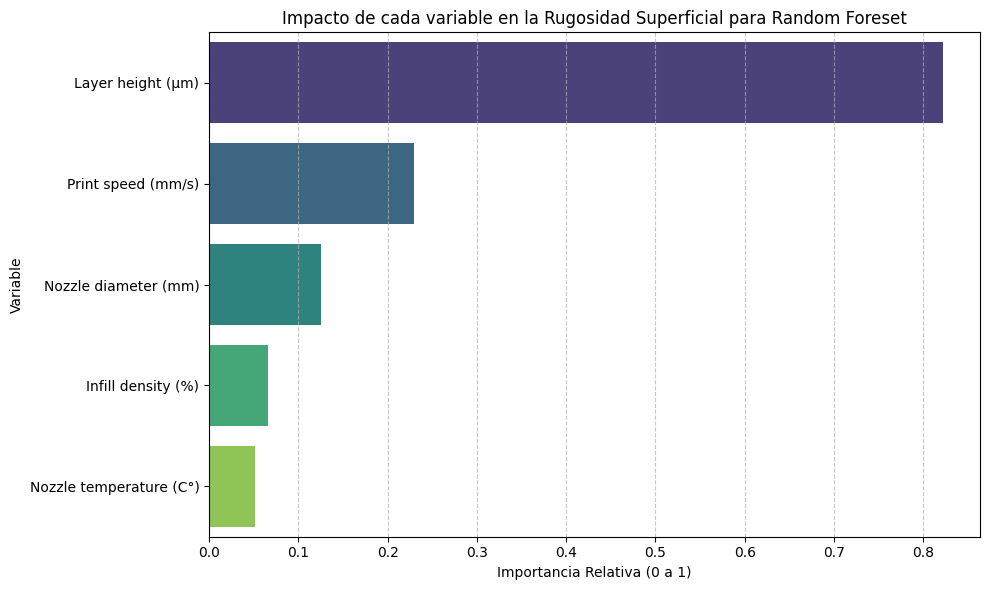

In [43]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia Media', y='Variable', data=rf_perm_importance, palette='viridis')
plt.title('Impacto de cada variable en la Rugosidad Superficial para Random Foreset')
plt.xlabel('Importancia Relativa (0 a 1)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [44]:
def calcular_importancia_manual(predict_function, X, y_true, feature_names, n_repeats=10):
    """
    Calcula la importancia por permutación manualmente.
    predict_function: Función que recibe X y devuelve y_pred (numérico).
    """
    # 1. Línea base (Score original)
    y_pred_base = predict_function(X)
    baseline_r2 = r2_score(y_true, y_pred_base)
    print(f"R² Base: {baseline_r2:.4f}")
    
    importancias = []
    
    # 2. Iterar por cada variable
    for i, _ in enumerate(feature_names):
        scores = []
        for _ in range(n_repeats):
            X_perm = X.copy()
            # Romper la relación de la variable i mezclándola
            np.random.shuffle(X_perm[:, i])
            
            # Predecir con la variable rota
            y_pred_perm = predict_function(X_perm)
            score_perm = r2_score(y_true, y_pred_perm)
            
            # La importancia es cuánto BAJÓ el score
            scores.append(baseline_r2 - score_perm)
        
        importancias.append(np.mean(scores))
    
    # Devolver DataFrame ordenado
    return pd.DataFrame({
        'Variable': feature_names,
        'Importancia': importancias
    }).sort_values('Importancia', ascending=False)

In [45]:
# --- Wrapper para KAN ---
# KAN necesita Tensores de PyTorch, no arrays de Numpy
def kan_predict(X):
    tensor_X = torch.from_numpy(X).float()
    pred = model_kan(tensor_X).detach().numpy()
    return pred.flatten()

In [46]:
df_imp_kan = calcular_importancia_manual(
    kan_predict, 
    X_test, 
    y_test.flatten(), 
    feature_cols
)

df_imp_kan.head()

R² Base: 0.9836


,Variable,Importancia
1,Layer height (μm),0.657
2,Print speed (mm/s),0.291
4,Infill density (%),0.144
3,Nozzle diameter (mm),0.127
0,Nozzle temperature (C°),0.044


C:\Users\Erick\AppData\Local\Temp\ipykernel_37972\4128712263.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp_kan, palette='viridis')


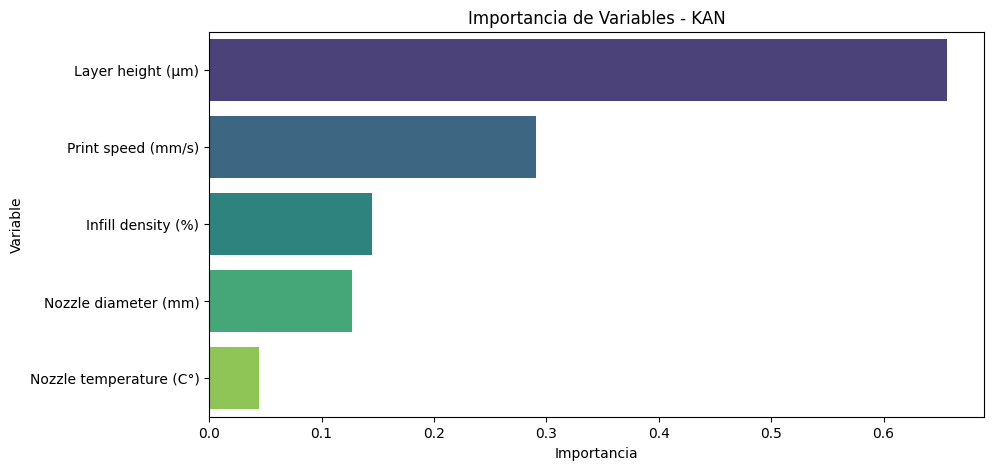

In [47]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp_kan, palette='viridis')
plt.title('Importancia de Variables - KAN')
plt.show()

In [48]:
# --- Wrapper para TabPFN ---
# TabPFN ya funciona bien con arrays, es directo
def tabpfn_predict(X):
    return regressor.predict(X).flatten()

In [49]:
df_imp_tab = calcular_importancia_manual(
    tabpfn_predict, 
    X_test, 
    y_test.flatten(), 
    feature_cols
)

df_imp_tab.head()

R² Base: 0.9639


,Variable,Importancia
1,Layer height (μm),0.658
2,Print speed (mm/s),0.312
3,Nozzle diameter (mm),0.203
4,Infill density (%),0.068
0,Nozzle temperature (C°),0.047


C:\Users\Erick\AppData\Local\Temp\ipykernel_37972\2428364163.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp_kan, palette='viridis')


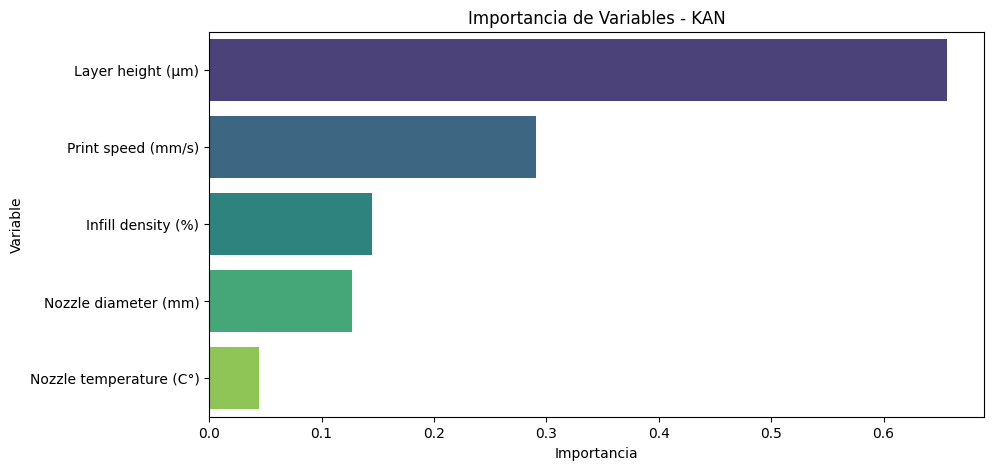

In [50]:
# Graficar
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp_kan, palette='viridis')
plt.title('Importancia de Variables - KAN')
plt.show()

In [51]:
# --- Wrapper para TabPFN ---
# TabPFN ya funciona bien con arrays, es directo
def tabpfn_predict(X):
    return regressor.predict(X).flatten()

In [52]:
df_imp_tab = calcular_importancia_manual(
    tabpfn_predict, 
    X_test, 
    y_test.flatten(), 
    feature_cols
)

df_imp_tab.head()

R² Base: 0.9639


,Variable,Importancia
1,Layer height (μm),0.669
2,Print speed (mm/s),0.333
3,Nozzle diameter (mm),0.250
4,Infill density (%),0.069
0,Nozzle temperature (C°),0.047


C:\Users\Erick\AppData\Local\Temp\ipykernel_37972\1643139355.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp_tab, palette='viridis')


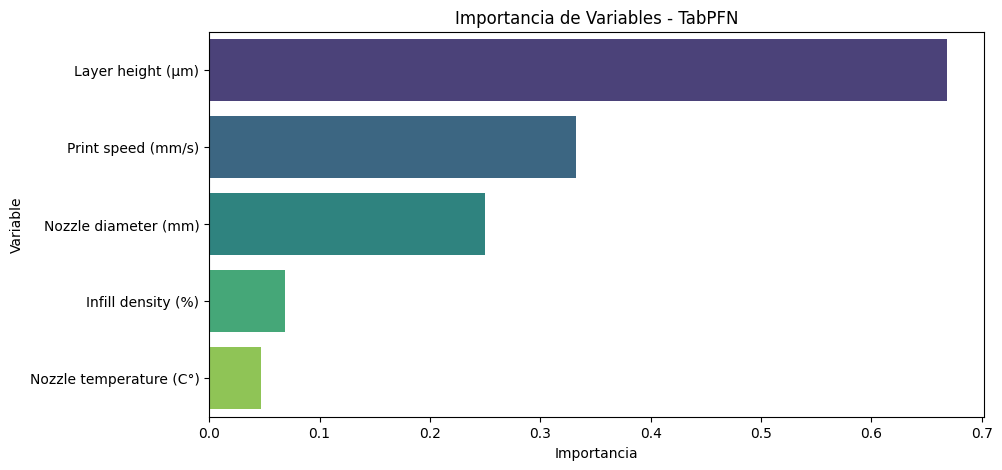

In [53]:
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=df_imp_tab, palette='viridis')
plt.title('Importancia de Variables - TabPFN')
plt.show()